# Import Required Libraries
Import necessary libraries such as pandas, numpy, matplotlib, seaborn, and any other required libraries.

In [57]:
# Import Required Libraries

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Data Imputation
from sklearn.impute import SimpleImputer

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Display plots inline within the Jupyter notebook
%matplotlib inline

# Load Data
Load the datasets ScoringNFL.csv, Umbrella.csv, Fortune500Sector.csv, EJB.csv, and Employee-Attritionv1.csv from the data folder.

In [58]:
# Load Data

# Load the ScoringNFL dataset
scoring_nfl_df = pd.read_csv('data/ScoringNFL.csv')

# Load the Umbrella dataset
umbrella_df = pd.read_csv('data/Umbrella.csv')

# Load the Fortune500Sector dataset
fortune500sector_df = pd.read_csv('data/Fortune500Sector.csv')

# Load the EJB dataset
ejb_df = pd.read_csv('data/EJB.csv')

# Load the Employee-Attrition dataset
employee_attrition_df = pd.read_csv('data/Employee-Attritionv1.csv')


In [59]:
# Handle Missing Values

# Initialize the SimpleImputer for numerical columns
num_imputer = SimpleImputer(strategy='mean')  # You can also use 'median'

# Fit and transform the numerical columns in the Employee-Attrition dataset
numerical_cols = employee_attrition_df.select_dtypes(include=['int64', 'float64']).columns
employee_attrition_df[numerical_cols] = num_imputer.fit_transform(employee_attrition_df[numerical_cols])

# Initialize the SimpleImputer for non-numerical columns
cat_imputer = SimpleImputer(strategy='most_frequent')  # You can also use 'constant'

# Fit and transform the non-numerical columns in the Employee-Attrition dataset
categorical_cols = employee_attrition_df.select_dtypes(include=['object']).columns
employee_attrition_df[categorical_cols] = cat_imputer.fit_transform(employee_attrition_df[categorical_cols])

# Check for missing values again to ensure they are handled
missing_values_after_imputation = employee_attrition_df.isnull().sum()
print("Missing Values in Employee-Attrition Dataset after Imputation:")
print(missing_values_after_imputation[missing_values_after_imputation > 0], "\n")

# Explanation:
# Handling missing values is crucial because they can affect the performance of machine learning models.
# Missing values can lead to biased estimates, reduce the statistical power of the analysis, and cause errors in the model training process.
# By imputing missing values, we improve the quality of the data, leading to more accurate and reliable machine learning models.

Missing Values in Employee-Attrition Dataset after Imputation:
Series([], dtype: int64) 



In [60]:

# Display the first few rows of each dataset to verify loading
print("ScoringNFL Dataset:")
scoring_nfl_df.head(3)


ScoringNFL Dataset:


,Team,Season,Points Scored
0,Baltimore Ravens,2010,357
1,San Francisco 49ers,2010,305
2,Tampa Bay Buccaneers,2010,341


In [61]:

# Display the first few rows of each dataset to verify loading
print("Umbrella Dataset:")
umbrella_df.head(3)

Umbrella Dataset:


,Year,Quarter,Sales (Thousands $)
0,1,I,125
1,1,II,153
2,1,III,106


In [62]:
print("Fortune500Sector Dataset:")
fortune500sector_df.head(3)

Fortune500Sector Dataset:


,Company,Sector,Profits ($ millions),Market Capitalization ($ millions)
0,Alliant Techsystems,Industrials,313.2,1891.9
1,Amazon.com,Consumer,631,81458.6
2,AmerisourceBergen,Healthcare,706.6,10087.6


In [63]:
print("EJB Dataset:")
ejb_df.head(3)

EJB Dataset:


,Order ID,Flavor,Category,$ Sales,Date Ordered,Date Delivered,Distribution Center,New Customer?,Service Satisfaction Rating,Product Satisfaction Rating,Unnamed: 10
0,92145,Beet,Juices,605.97,1/1/2018,1/3/2018,ID,Yes,3.0,NaN,NaN
1,92145,Apple,Juices,1549.00,1/1/2018,1/3/2018,ID,Yes,5.0,4.0,NaN
2,92145,Apple,Juices,1986.28,1/1/2018,1/3/2018,ID,Yes,5.0,4.0,NaN


In [64]:
print("Employee-Attrition Dataset:")
employee_attrition_df.head(3)

Employee-Attrition Dataset:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41.0,Yes,Travel_Rarely,1102.0,Sales,1.0,2.0,Life Sciences,1.0,1.0,...,1.0,80.0,0.0,8.0,0.0,1.0,6.0,4.0,0.0,5.0
1,49.0,No,Travel_Frequently,279.0,Research & Development,8.0,1.0,Life Sciences,1.0,2.0,...,4.0,80.0,1.0,10.0,3.0,3.0,10.0,7.0,1.0,7.0
2,37.0,Yes,Travel_Rarely,1373.0,Research & Development,2.0,2.0,Other,1.0,4.0,...,2.0,80.0,0.0,7.0,3.0,3.0,0.0,0.0,0.0,0.0


# 1 a. Distribution of Scoring Over 10 Seasons
Construct a single chart to compare the distribution of scoring across the league over 10 seasons using the ScoringNFL.csv data.

A boxplot is a chart that summarizes distribution of a data to provide insights into the spread, central tendency and outliers within a data.

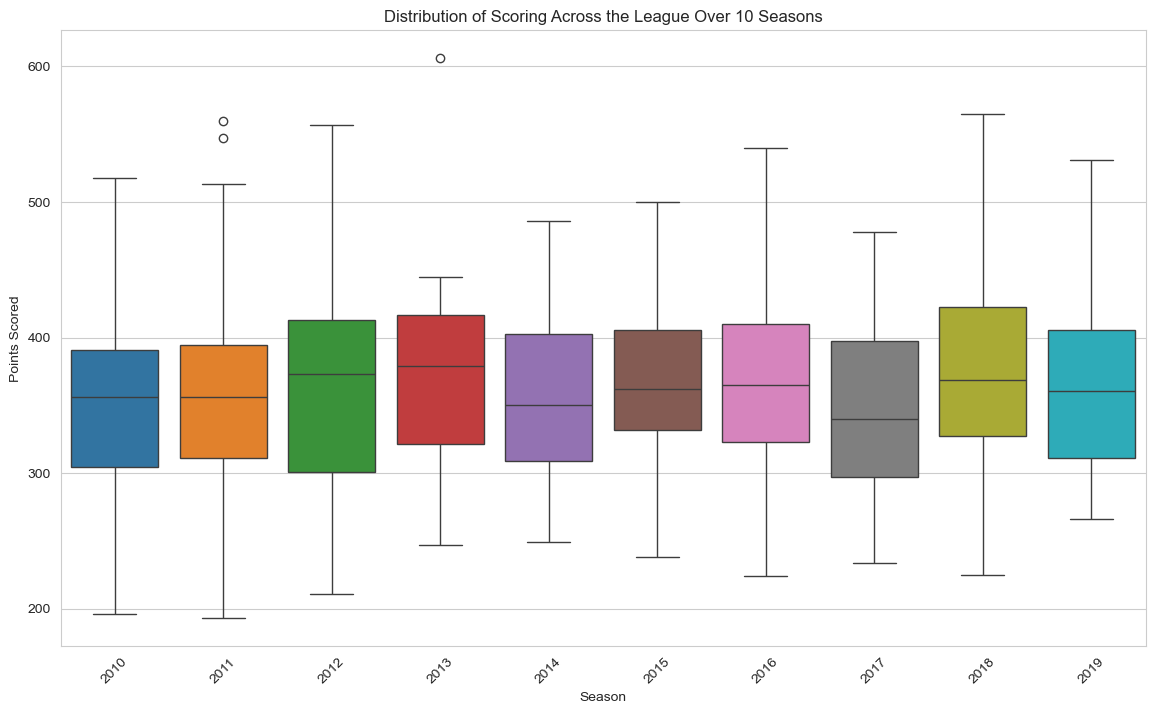

Season 2010 outliers:
Series([], Name: 2010, dtype: int64)

Season 2011 outliers:
Team
Green Bay Packers     560
New Orleans Saints    547
Name: 2011, dtype: int64

Season 2012 outliers:
Series([], Name: 2012, dtype: int64)

Season 2013 outliers:
Team
Denver Broncos    606
Name: 2013, dtype: int64

Season 2014 outliers:
Series([], Name: 2014, dtype: int64)

Season 2015 outliers:
Series([], Name: 2015, dtype: int64)

Season 2016 outliers:
Series([], Name: 2016, dtype: int64)

Season 2017 outliers:
Series([], Name: 2017, dtype: int64)

Season 2018 outliers:
Series([], Name: 2018, dtype: int64)

Season 2019 outliers:
Series([], Name: 2019, dtype: int64)



In [65]:
# Distribution of Scoring Over 10 Seasons

# Pivot the data to have seasons as columns and teams as rows
scoring_pivot = scoring_nfl_df.pivot(index='Team', columns='Season', values='Points Scored')

# Plot the distribution of scoring across the league over 10 seasons
plt.figure(figsize=(14, 8))
sns.boxplot(data=scoring_pivot)
plt.title('Distribution of Scoring Across the League Over 10 Seasons')
plt.xlabel('Season')
plt.ylabel('Points Scored')
plt.xticks(rotation=45)
plt.show()

# Function to find outliers for each season
def find_outliers(df):
    outliers = {}
    for season in df.columns:
        Q1 = df[season].quantile(0.25)
        Q3 = df[season].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        season_outliers = df[(df[season] < lower_bound) | (df[season] > upper_bound)][season]
        outliers[season] = season_outliers
    return outliers

# Find outliers
outliers = find_outliers(scoring_pivot)

# Print outliers
for season, outlier_values in outliers.items():
    print(f"Season {season} outliers:")
    print(outlier_values)
    print()

Outliers in NFL Scoring by Season

| Season | Team                | Points Scored |
|--------|---------------------|---------------|
| 2011   | Green Bay Packers   | 560           |
| 2011   | New Orleans Saints  | 547           |
| 2013   | Denver Broncos      | 606           |

Green Bay Packers and New Orleans Saints show an exceptional performance in 2011 of 560 and 547 respectively
and Denver Broncos has a performance of 606 in 2013 that is beyond the 75th percentile.


Over the past decade, the distribution of scoring in the NFL has shown considerable variation, with certain teams and seasons standing out due to exceptionally high offensive performances. While most teams' point totals fell within a typical range, a few outliers significantly exceeded the league average, highlighting moments of offensive dominance.

In the 2011 season, both the Green Bay Packers and the New Orleans Saints demonstrated outstanding scoring ability, with the Packers recording 560 points and the Saints following closely behind with 547. These totals placed them well beyond the typical scoring range for that season, positioning them among the highest-scoring teams in NFL history at the time. Similarly, in 2013, the Denver Broncos reached an even greater milestone by scoring 606 points, setting a new benchmark for offensive production. These performances were well above the 75th percentile of scoring distribution, marking them as statistical outliers in their respective seasons.

The presence of such extreme performances suggests a right-skewed distribution of scoring, where most teams scored within a moderate range while a few recorded exceptionally high totals. This pattern indicates variability in offensive efficiency across the league, with certain teams benefiting from elite quarterback play, innovative offensive strategies, or favorable rule changes that emphasized passing and high-scoring games.

Over time, these trends reflect a broader evolution in the NFL, where offenses have become more dynamic and high-powered. Factors such as changes in coaching philosophies, advancements in play-calling, and rule modifications favoring offensive players have contributed to an overall increase in scoring. However, the dominance of a few teams in certain seasons also raises questions about competitive balance, as some franchises consistently outperform their rivals due to stronger rosters, better coaching, or structural advantages.

Ultimately, the data highlights both the growing offensive explosiveness in the NFL and the impact of standout teams that redefine scoring expectations. The Green Bay Packers, New Orleans Saints, and Denver Broncos each had seasons that pushed the boundaries of what was considered possible in terms of offensive production, shaping the league's scoring landscape over the past decade.


In [66]:
# Checking skewness

# Calculate skewness for each season
skewness_values = scoring_pivot.skew()

# Print skewness for each season
print("Skewness for each season:")
print(skewness_values)


Skewness for each season:
Season
2010    0.086797
2011    0.432348
2012    0.186152
2013    0.866538
2014    0.289207
2015    0.228294
2016    0.213602
2017    0.283363
2018    0.415105
2019    0.475553
dtype: float64


In [67]:
from scipy.stats import skew

# Apply skew function to each season
skewness_values = scoring_pivot.apply(skew, axis=0)  # axis=0 means column-wise (per season)

# Print skewness for each season
print("Skewness for each season:")
print(skewness_values)


Skewness for each season:
Season
2010    0.082674
2011    0.411812
2012    0.177310
2013    0.825378
2014    0.275470
2015    0.217450
2016    0.203456
2017    0.269903
2018    0.395388
2019    0.452965
dtype: float64


# Temporal Patterns in Scoring for Individual Teams
Unstack the data and use sparklines to show how scoring for each team has changed over 10 seasons. Identify teams with strong upward and downward trends.

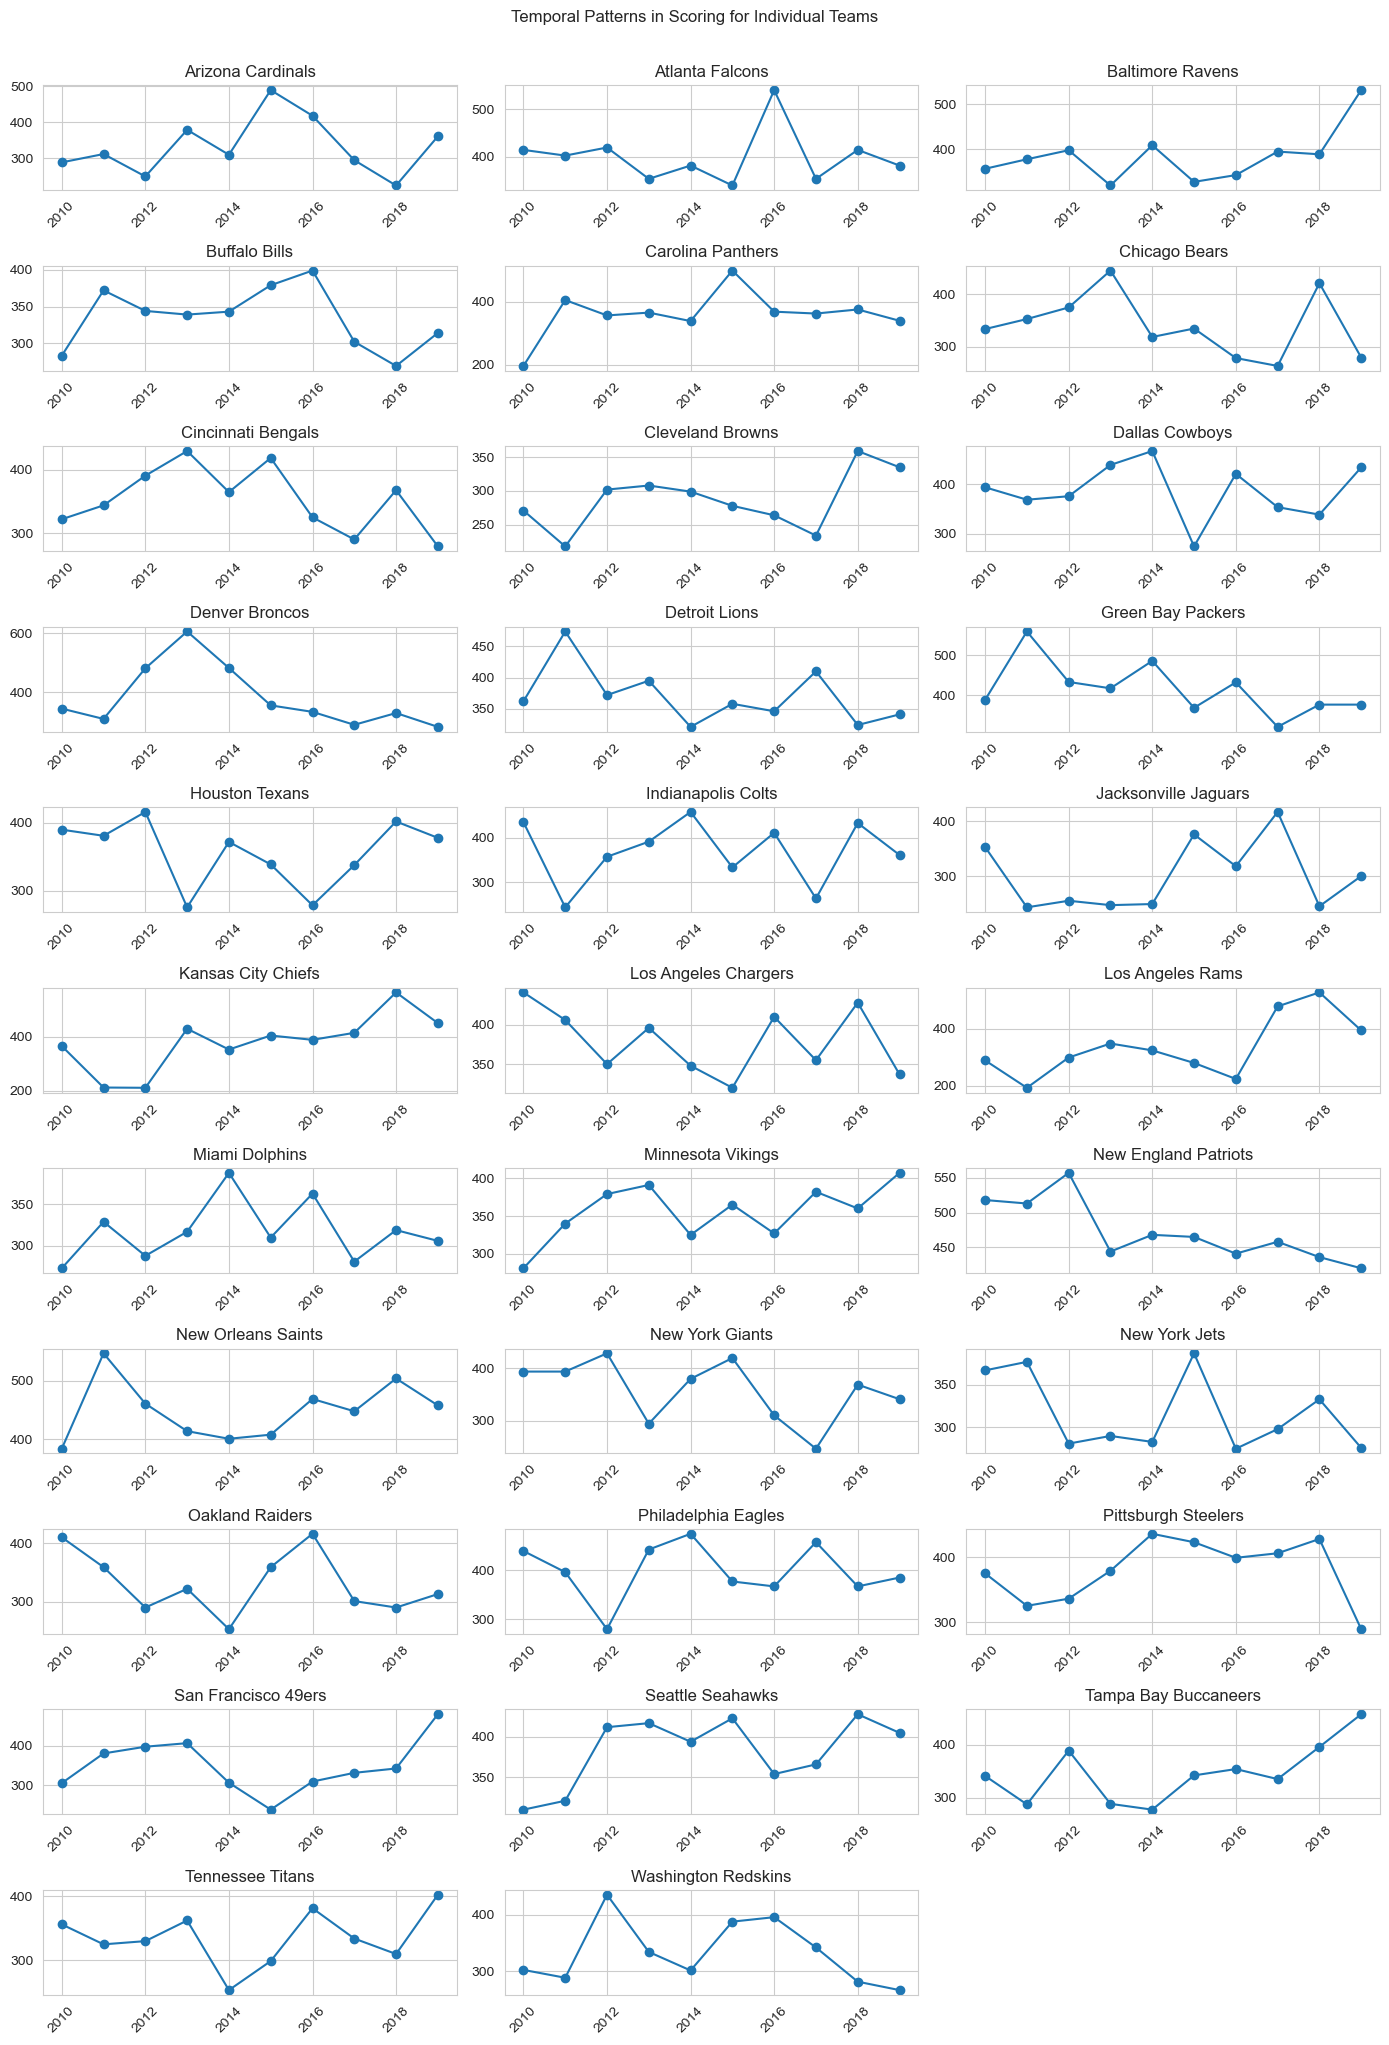

Team with strong upward trend: Kansas City Chiefs
Team with strong downward trend: Denver Broncos


In [68]:
# Temporal Patterns in Scoring for Individual Teams

# Unstack the data to have seasons as columns and teams as rows
scoring_unstacked = scoring_nfl_df.pivot(index='Team', columns='Season', values='Points Scored')

# Plot sparklines for each team to show how scoring has changed over 10 seasons
plt.figure(figsize=(14, 20))
for i, team in enumerate(scoring_unstacked.index):
    plt.subplot(len(scoring_unstacked.index) // 3 + 1, 3, i + 1)
    plt.plot(scoring_unstacked.columns, scoring_unstacked.loc[team], marker='o')
    plt.title(team)
    plt.xticks(rotation=45)
    plt.tight_layout()

plt.suptitle('Temporal Patterns in Scoring for Individual Teams', y=1.02)
plt.show()

# Calculate the trend for each team
scoring_trends = scoring_unstacked.apply(lambda x: np.polyfit(scoring_unstacked.columns, x, 1)[0], axis=1)

# Identify teams with strong upward and downward trends
strong_upward_trend_team = scoring_trends.idxmax()
strong_downward_trend_team = scoring_trends.idxmin()

print(f"Team with strong upward trend: {strong_upward_trend_team}")
print(f"Team with strong downward trend: {strong_downward_trend_team}")

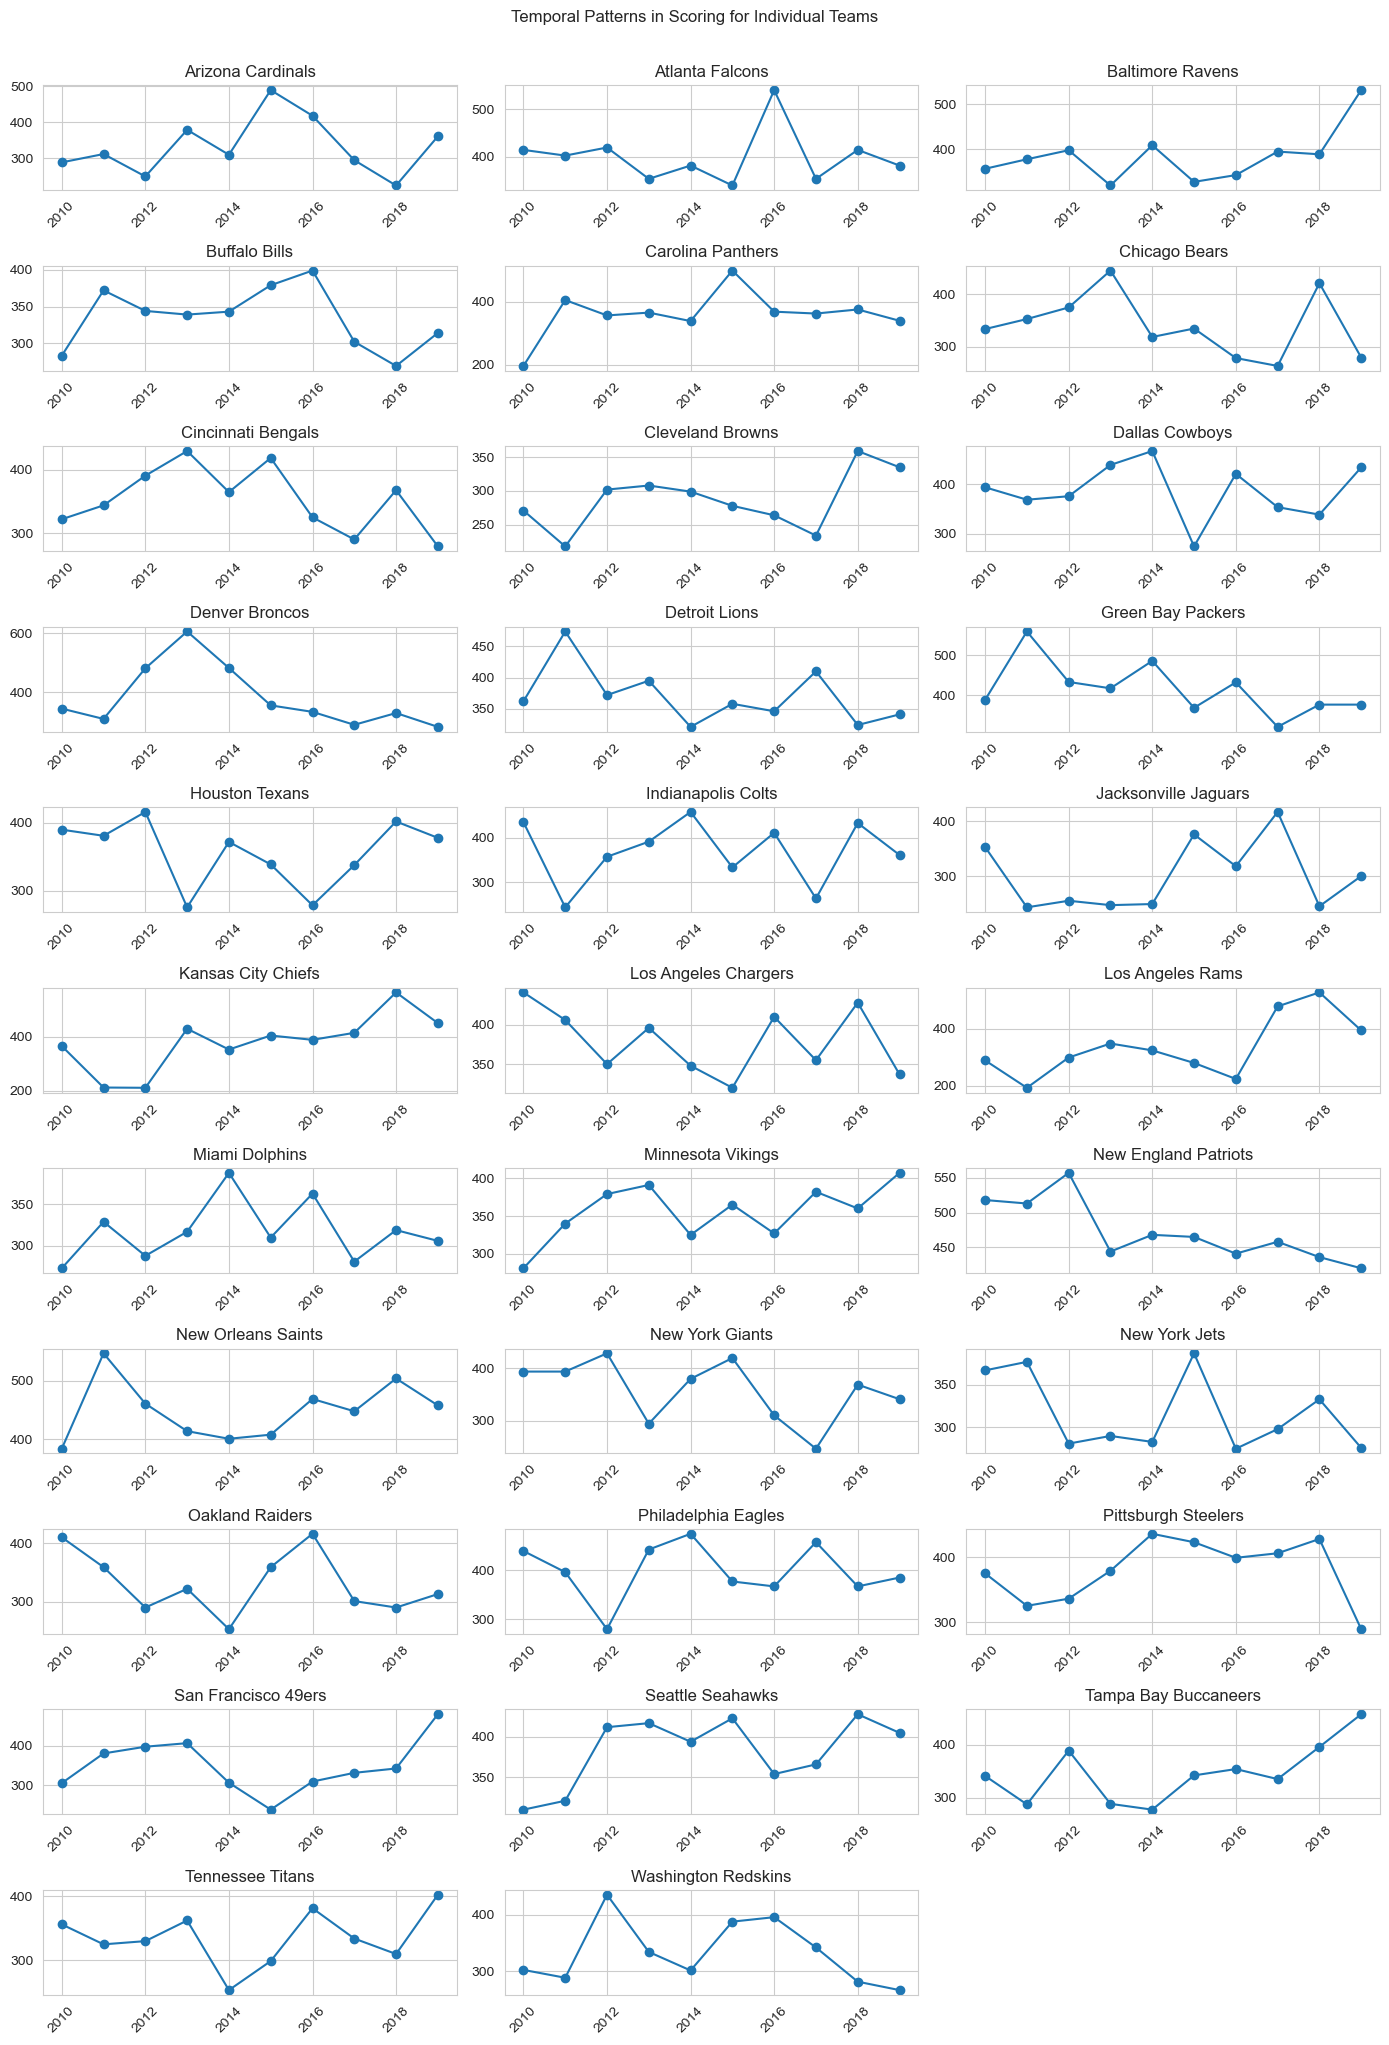

Teams with the strongest upward trends:
Kansas City Chiefs: 25.36
Los Angeles Rams: 22.80
Tampa Bay Buccaneers: 10.96
Baltimore Ravens: 9.79
Carolina Panthers: 7.79

Teams with the strongest downward trends:
Detroit Lions: -7.02
New York Giants: -8.96
New England Patriots: -11.68
Green Bay Packers: -12.33
Denver Broncos: -14.08

Team with the strongest upward trend: Kansas City Chiefs
Team with the strongest downward trend: Denver Broncos


In [69]:
# Unstack the data to have seasons as columns and teams as rows
scoring_unstacked = scoring_nfl_df.pivot(index='Team', columns='Season', values='Points Scored')

# Plot sparklines for each team to show how scoring has changed over 10 seasons
plt.figure(figsize=(14, 20))
for i, team in enumerate(scoring_unstacked.index):
    plt.subplot(len(scoring_unstacked.index) // 3 + 1, 3, i + 1)
    plt.plot(scoring_unstacked.columns, scoring_unstacked.loc[team], marker='o')
    plt.title(team)
    plt.xticks(rotation=45)
    plt.tight_layout()

plt.suptitle('Temporal Patterns in Scoring for Individual Teams', y=1.02)
plt.show()

# Calculate the trend for each team
scoring_trends = scoring_unstacked.apply(lambda x: np.polyfit(scoring_unstacked.columns, x, 1)[0], axis=1)

# Sort teams by trend
sorted_teams_by_trend = scoring_trends.sort_values(ascending=False)

# Print the list of teams with the strongest upward trends
print("Teams with the strongest upward trends:")
for team, trend in sorted_teams_by_trend.head(5).items():
    print(f"{team}: {trend:.2f}")

# Print the list of teams with the strongest downward trends
print("\nTeams with the strongest downward trends:")
for team, trend in sorted_teams_by_trend.tail(5).items():
    print(f"{team}: {trend:.2f}")

# Identify teams with strong upward and downward trends
strong_upward_trend_team = sorted_teams_by_trend.idxmax()
strong_downward_trend_team = sorted_teams_by_trend.idxmin()

print(f"\nTeam with the strongest upward trend: {strong_upward_trend_team}")
print(f"Team with the strongest downward trend: {strong_downward_trend_team}")

# Line Chart for Sales Time Series Data
Create a line chart for the sales time series data from Umbrella.csv.

### Four-Period Moving Average
Add a four-period moving average to the sales time series chart to smooth the data.

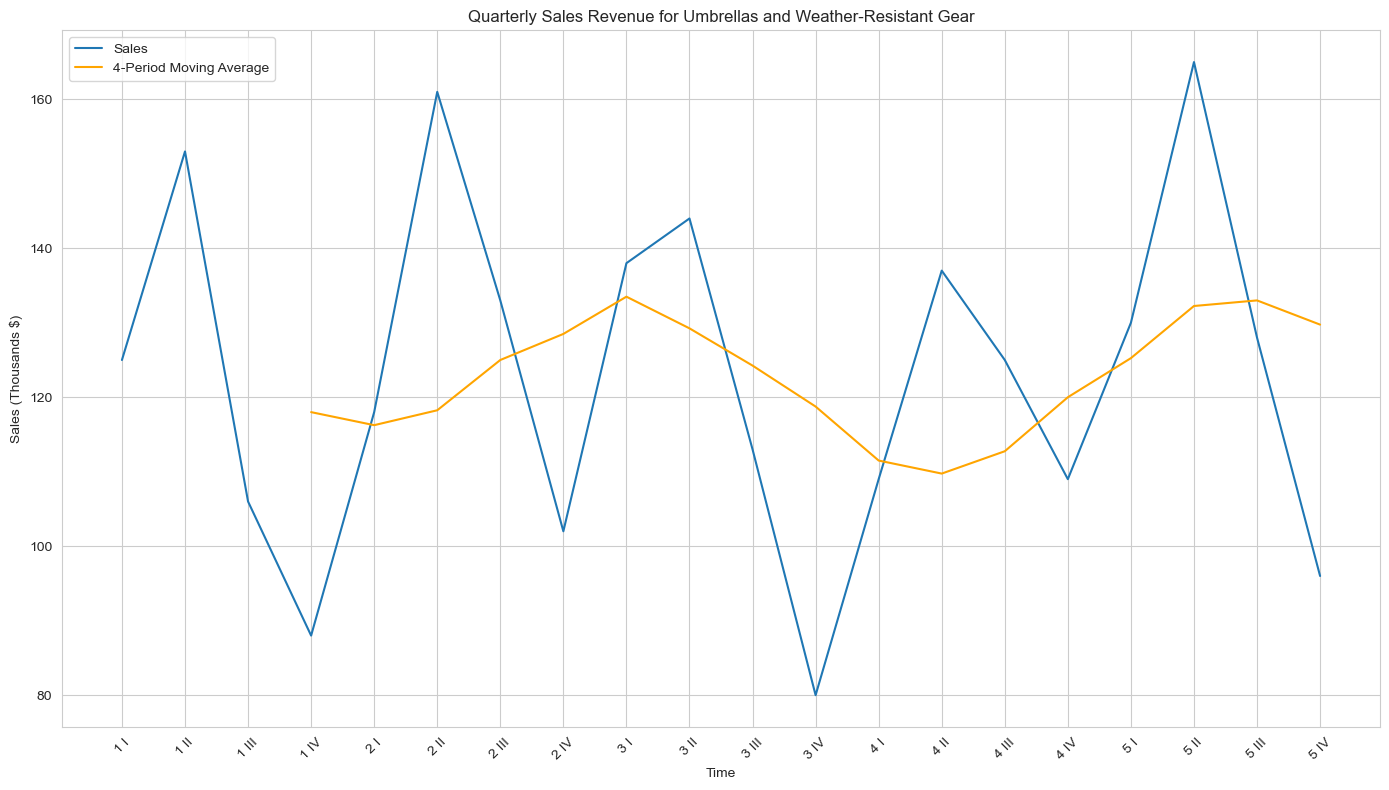

In [70]:
# Create a line chart for the sales time series data
plt.figure(figsize=(14, 8))
plt.plot(umbrella_df['Year'].astype(str) + ' ' + umbrella_df['Quarter'], umbrella_df['Sales (Thousands $)'], label='Sales')

# Add a four-period moving average to the chart to smooth the data
umbrella_df['Four-Period Moving Average'] = umbrella_df['Sales (Thousands $)'].rolling(window=4).mean()
plt.plot(umbrella_df['Year'].astype(str) + ' ' + umbrella_df['Quarter'], umbrella_df['Four-Period Moving Average'], label='4-Period Moving Average', color='orange')

# Customize the plot
plt.title('Quarterly Sales Revenue for Umbrellas and Weather-Resistant Gear')
plt.xlabel('Time')
plt.ylabel('Sales (Thousands $)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()

# Show the plot
plt.show()

# Seasonality Analysis
Plot the data as a collection of five data series (one for each year) to investigate seasonality in the Umbrella.csv data.

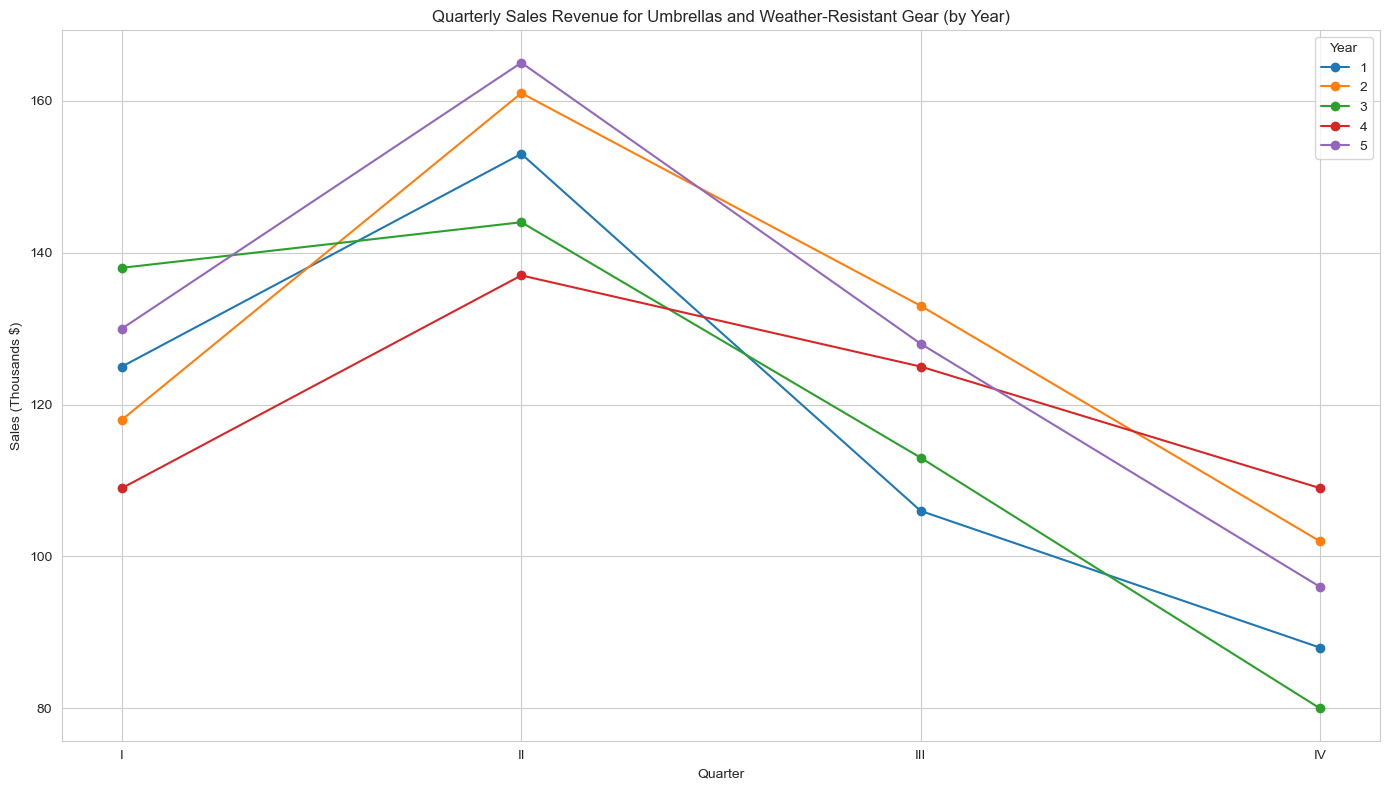

In [71]:
# Pivot the data to have quarters as columns and years as rows
umbrella_pivot = umbrella_df.pivot(index='Year', columns='Quarter', values='Sales (Thousands $)')

# Plot the data as a collection of five data series (one for each year)
plt.figure(figsize=(14, 8))
for year in umbrella_pivot.index:
    plt.plot(umbrella_pivot.columns, umbrella_pivot.loc[year], marker='o', label=str(year))

# Customize the plot
plt.title('Quarterly Sales Revenue for Umbrellas and Weather-Resistant Gear (by Year)')
plt.xlabel('Quarter')
plt.ylabel('Sales (Thousands $)')
plt.legend(title='Year')
plt.grid(True)
plt.tight_layout()

# Show the plot
plt.show()

In [72]:
# Print the pivoted data to interpret the results
print("Quarterly Sales Revenue for Umbrellas and Weather-Resistant Gear (by Year):")
print(umbrella_pivot)

Quarterly Sales Revenue for Umbrellas and Weather-Resistant Gear (by Year):
Quarter    I   II  III   IV
Year                       
1        125  153  106   88
2        118  161  133  102
3        138  144  113   80
4        109  137  125  109
5        130  165  128   96


There is an indication of seasonality in the quarterly sales revenue for umbrellas and weather-resistant gear. Specifically:

Sales consistently peak in Q2 (April to June) across multiple years, suggesting a seasonal trend where demand for umbrellas and weather-resistant gear is higher during this period.
Sales tend to be lower in Q4 (October to December) across multiple years, indicating a seasonal dip in demand during this period.

These observations suggest that the manufacturer experiences higher sales in the second quarter and lower sales in the fourth quarter, likely due to seasonal factors such as weather patterns and consumer behavior.

# Scatter Chart for Market Capitalization and Profit
Prepare a scatter chart to show the relationship between Market Capitalization and Profit using Fortune500Sector.csv data.

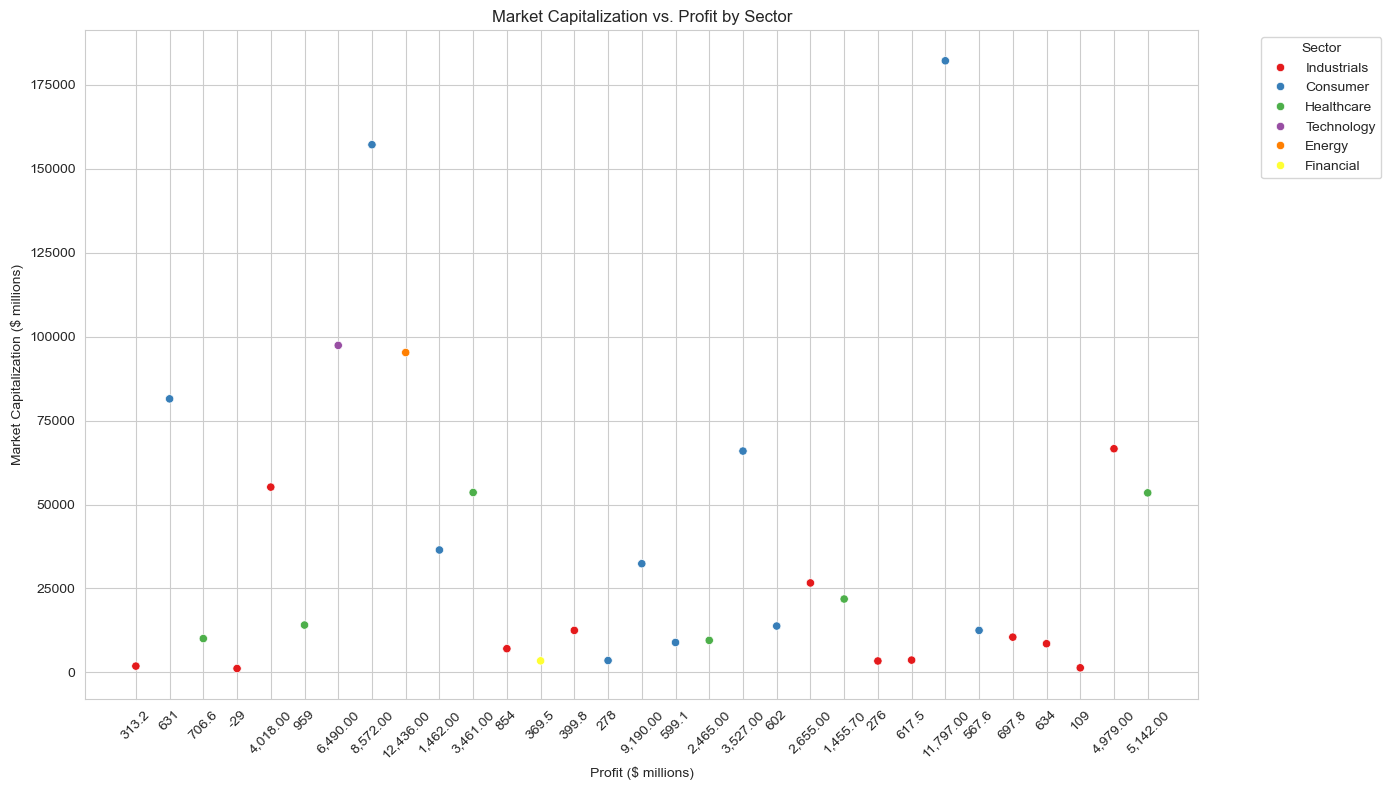

In [73]:


# Prepare a scatter chart to show the relationship between Market Capitalization and Profit
plt.figure(figsize=(14, 8))
sns.scatterplot(data=fortune500sector_df, x='Profits ($ millions)', y='Market Capitalization ($ millions)', hue='Sector', palette='Set1')

# Customize the plot
plt.title('Market Capitalization vs. Profit by Sector')
plt.xlabel('Profit ($ millions)')
plt.ylabel('Market Capitalization ($ millions)')
plt.legend(title='Sector', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

# Show the plot
plt.show()

# Emphasize Healthcare Sector
Format all other sectors with gray data points and create a trendline based on the healthcare sector observations.

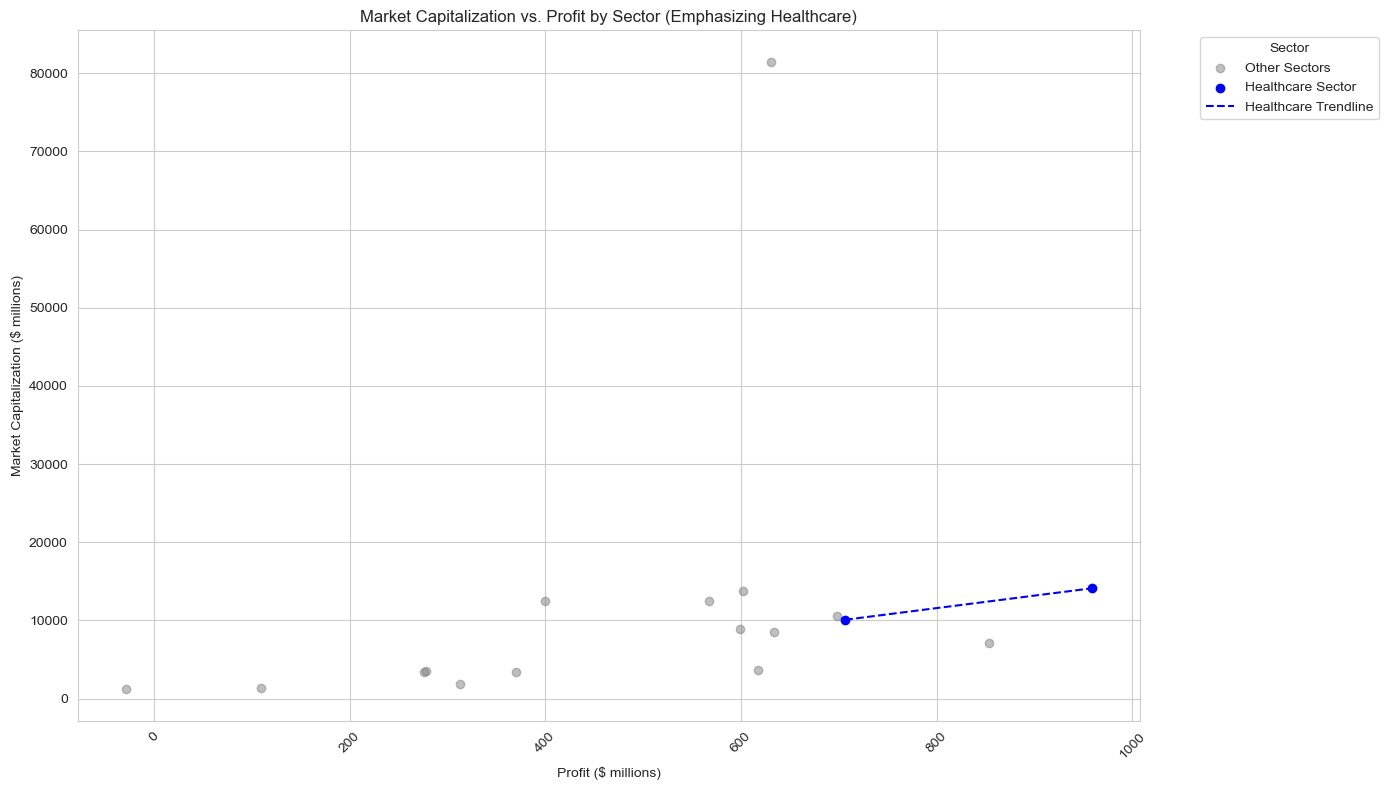

Trendline equation for Healthcare Sector: Market Capitalization = 15.96 * Profit + -1187.77


In [74]:
# Ensure the columns are numeric
fortune500sector_df['Profits ($ millions)'] = pd.to_numeric(fortune500sector_df['Profits ($ millions)'], errors='coerce')
fortune500sector_df['Market Capitalization ($ millions)'] = pd.to_numeric(fortune500sector_df['Market Capitalization ($ millions)'], errors='coerce')

# Drop rows with missing values
fortune500sector_df.dropna(subset=['Profits ($ millions)', 'Market Capitalization ($ millions)'], inplace=True)

# Separate the healthcare sector data
healthcare_df = fortune500sector_df[fortune500sector_df['Sector'] == 'Healthcare']
other_sectors_df = fortune500sector_df[fortune500sector_df['Sector'] != 'Healthcare']

# Prepare a scatter chart
plt.figure(figsize=(14, 8))

# Plot other sectors in gray with no fill
plt.scatter(other_sectors_df['Profits ($ millions)'], other_sectors_df['Market Capitalization ($ millions)'], color='gray', alpha=0.5, label='Other Sectors')

# Plot healthcare sector with a different color
plt.scatter(healthcare_df['Profits ($ millions)'], healthcare_df['Market Capitalization ($ millions)'], color='blue', label='Healthcare Sector')

# Create a trendline for the healthcare sector
z = np.polyfit(healthcare_df['Profits ($ millions)'], healthcare_df['Market Capitalization ($ millions)'], 1)
p = np.poly1d(z)
plt.plot(healthcare_df['Profits ($ millions)'], p(healthcare_df['Profits ($ millions)']), color='blue', linestyle='--', label='Healthcare Trendline')

# Customize the plot
plt.title('Market Capitalization vs. Profit by Sector (Emphasizing Healthcare)')
plt.xlabel('Profit ($ millions)')
plt.ylabel('Market Capitalization ($ millions)')
plt.legend(title='Sector', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

# Show the plot
plt.show()

# Interpretation of the trendline
print(f"Trendline equation for Healthcare Sector: Market Capitalization = {z[0]:.2f} * Profit + {z[1]:.2f}")

The trendline indicates that within the healthcare sector, higher profits are associated with higher market capitalizations. The positive slope suggests a strong positive relationship, meaning that as companies in the healthcare sector become more profitable, their market capitalization tends to increase significantly. This relationship highlights the importance of profitability in driving the market value of healthcare companies.

# Relative Frequency Distribution of Category
Construct the relative frequency distribution of records over the values of the Category variable in EJB.csv.

In [80]:
# Display the first few rows of the dataset
ejb_df.head()

,Order ID,Flavor,Category,$ Sales,Date Ordered,Date Delivered,Distribution Center,New Customer?,Service Satisfaction Rating,Product Satisfaction Rating,Unnamed: 10
0,92145,Beet,Juices,605.97,1/1/2018,1/3/2018,ID,New,3.0,NaN,NaN
1,92145,Apple,Juices,1549.00,1/1/2018,1/3/2018,ID,New,5.0,4.0,NaN
2,92145,Apple,Juices,1986.28,1/1/2018,1/3/2018,ID,New,5.0,4.0,NaN
3,92145,Orange,Juices,16.43,1/1/2018,1/3/2018,ID,New,5.0,3.0,NaN
4,92145,Cucumber,Juices,1594.93,1/1/2018,1/3/2018,ID,New,NaN,NaN,NaN


Relative Frequency Distribution of Category:
Category
Juices       0.551703
Smoothies    0.448297
Name: proportion, dtype: float64

Findings for Category:
The relative frequency distribution shows the proportion of records for each category.
For example, if 'Juices' has a relative frequency of 0.60, it means that 60% of the records belong to the 'Juices' category.


<Figure size 1500x1000 with 0 Axes>

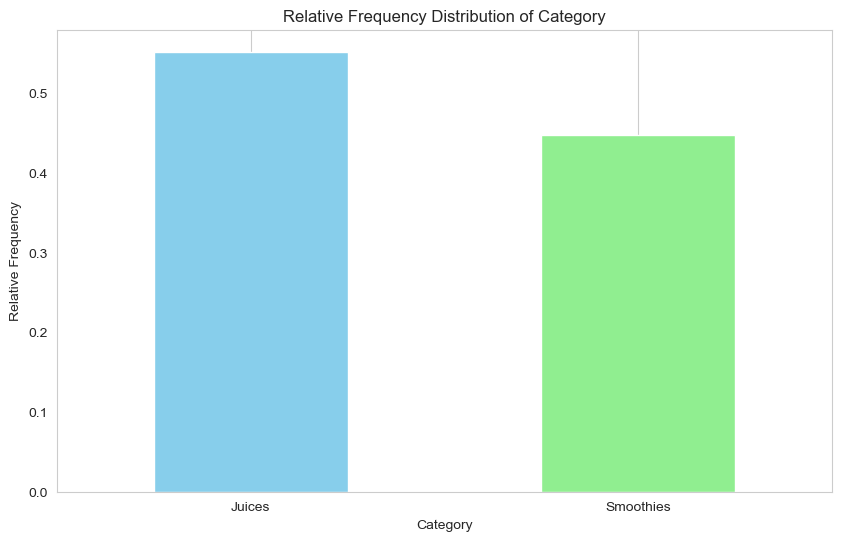

In [82]:
# Construct the relative frequency distribution for the Category variable
category_freq = ejb_df['Category'].value_counts(normalize=True)

# Print the relative frequency distribution
print("Relative Frequency Distribution of Category:")
print(category_freq)

# Describe the findings
print("\nFindings for Category:")
print("The relative frequency distribution shows the proportion of records for each category.")
print("For example, if 'Juices' has a relative frequency of 0.60, it means that 60% of the records belong to the 'Juices' category.")

# Plot the relative frequency distribution
plt.figure(figsize=(10, 6))
category_freq.plot(kind='bar', color=['skyblue', 'lightgreen'])
plt.title('Relative Frequency Distribution of Category')
plt.xlabel('Category')
plt.ylabel('Relative Frequency')
plt.xticks(rotation=0)
plt.grid(axis='y')

# Show the plot
plt.show()

Juices are the more common category, accounting for over half of the records (55.17%).

Smoothies also represent a substantial portion of the dataset, making up 44.83% of the records.

The distribution indicates that both categories are well-represented, with Juices being slightly more prevalent.

This relative frequency distribution helps us understand the composition of the dataset in terms of product categories, highlighting that Juices are slightly more common than Smoothies.

# Relative Frequency Distribution of New Customer
Construct the relative frequency distribution of records over the values of the New Customer variable in EJB.csv and relabel values.

In [85]:
# Relabel the values for the New Customer variable
ejb_df['New Customer'] = ejb_df['New Customer?'].replace({'No': 'Existing', 'Yes': 'New'})

In [86]:
# Construct the relative frequency distribution for the New Customer variable
new_customer_freq = ejb_df['New Customer'].value_counts(normalize=True)

# Print the relative frequency distribution
print("\nRelative Frequency Distribution of New Customer:")
print(new_customer_freq)

# Describe the findings
print("\nFindings for New Customer:")
print("The relative frequency distribution shows the proportion of records for new and existing customers.")
print("For example, if 'New' has a relative frequency of 0.30, it means that 30% of the records are for new customers, while the remaining 70% are for existing customers.")


Relative Frequency Distribution of New Customer:
New Customer
Existing    0.792635
New         0.207365
Name: proportion, dtype: float64

Findings for New Customer:
The relative frequency distribution shows the proportion of records for new and existing customers.
For example, if 'New' has a relative frequency of 0.30, it means that 30% of the records are for new customers, while the remaining 70% are for existing customers.


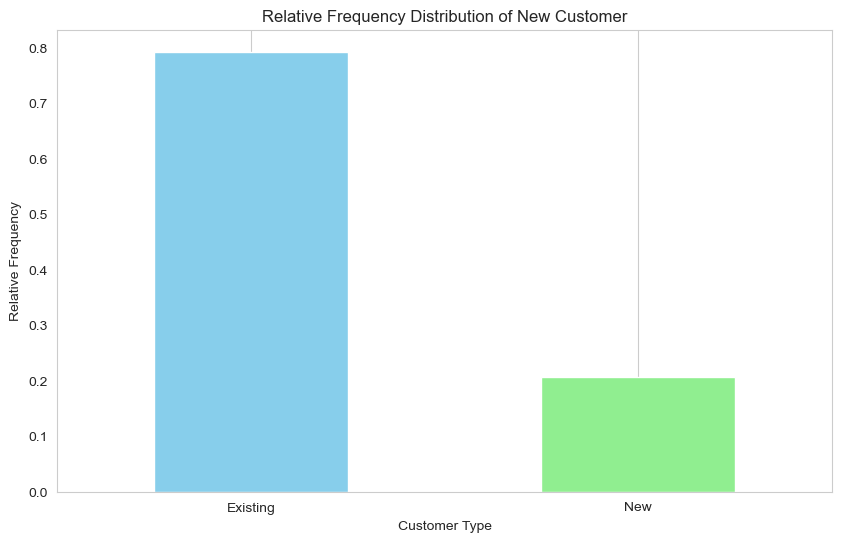

In [87]:
# Plot the relative frequency distribution
plt.figure(figsize=(10, 6))
new_customer_freq.plot(kind='bar', color=['skyblue', 'lightgreen'])
plt.title('Relative Frequency Distribution of New Customer')
plt.xlabel('Customer Type')
plt.ylabel('Relative Frequency')
plt.xticks(rotation=0)
plt.grid(axis='y')

# Show the plot
plt.show()

A majority of the records (79.26%) are for existing customers, while a smaller portion (20.74%) are for new customers.

This distribution indicates that the company has a strong focus on retaining existing customers, which is a positive sign of customer loyalty and satisfaction.

However, the company may also want to consider strategies to increase the acquisition of new customers to ensure continued growth and market expansion.

This relative frequency distribution helps us understand the composition of the dataset in terms of customer types, highlighting the importance of both retaining existing customers and acquiring new ones.

# Analysis of Missing Data in Product Satisfaction Rating
Construct the relative frequency distribution of records over the values of the Product Satisfaction Rating variable in EJB.csv and analyze missing data.

Relative Frequency Distribution of Product Satisfaction Rating:
Product Satisfaction Rating
NaN    0.532159
5.0    0.173640
4.0    0.085591
2.0    0.085491
3.0    0.083434
1.0    0.039685
Name: proportion, dtype: float64


C:\Users\kevin\AppData\Local\Temp\ipykernel_12184\1600657111.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=product_satisfaction_freq.index, y=product_satisfaction_freq.values, palette='viridis')


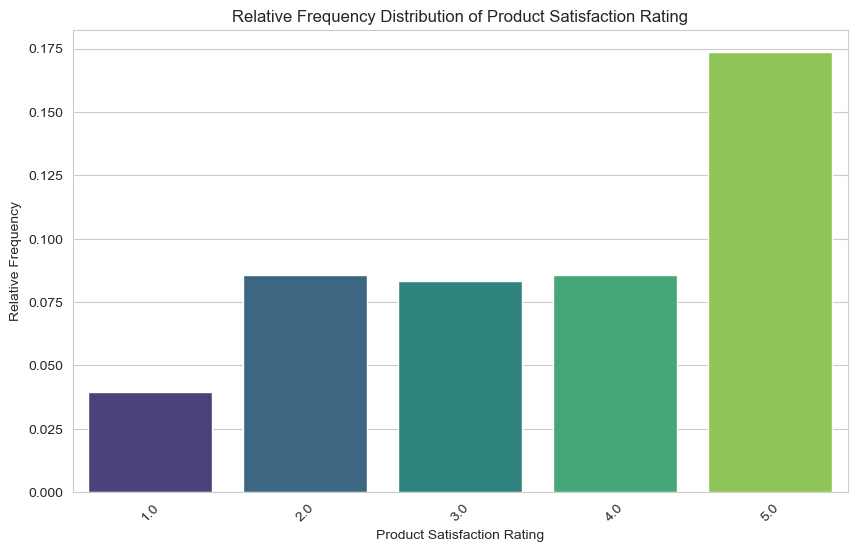

Percentage of records missing Product Satisfaction Rating: 53.22%
Relative Frequency Distribution of Flavors (Reported Satisfaction Ratings):
Flavor
Apple       0.131153
Orange      0.128686
Pear        0.126649
Cucumber    0.126005
Grape       0.123968
Carrot      0.121287
Celery      0.107668
Beet        0.068311
Tomato      0.066273
Name: proportion, dtype: float64


C:\Users\kevin\AppData\Local\Temp\ipykernel_12184\1600657111.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=flavor_freq_reported.index, y=flavor_freq_reported.values, palette='viridis')


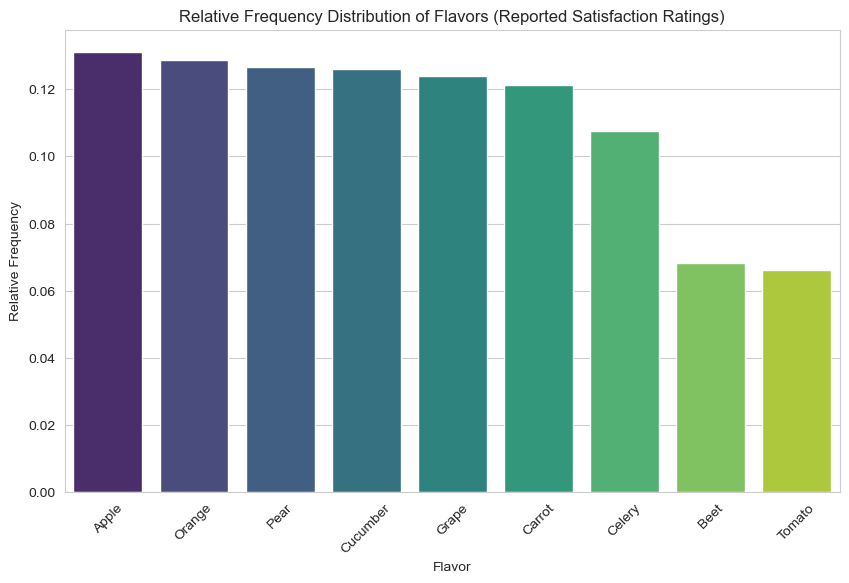

Relative Frequency Distribution of Flavors (Missing Satisfaction Ratings):
Flavor
Orange      0.184990
Apple       0.141995
Pear        0.125495
Grape       0.123798
Carrot      0.112106
Cucumber    0.108806
Celery      0.086649
Tomato      0.058175
Beet        0.057986
Name: proportion, dtype: float64


C:\Users\kevin\AppData\Local\Temp\ipykernel_12184\1600657111.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=flavor_freq_missing.index, y=flavor_freq_missing.values, palette='viridis')


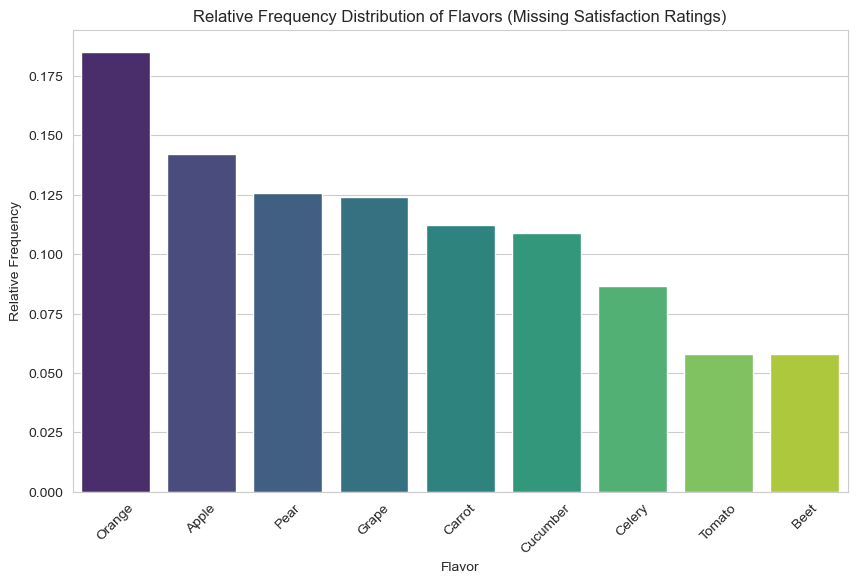

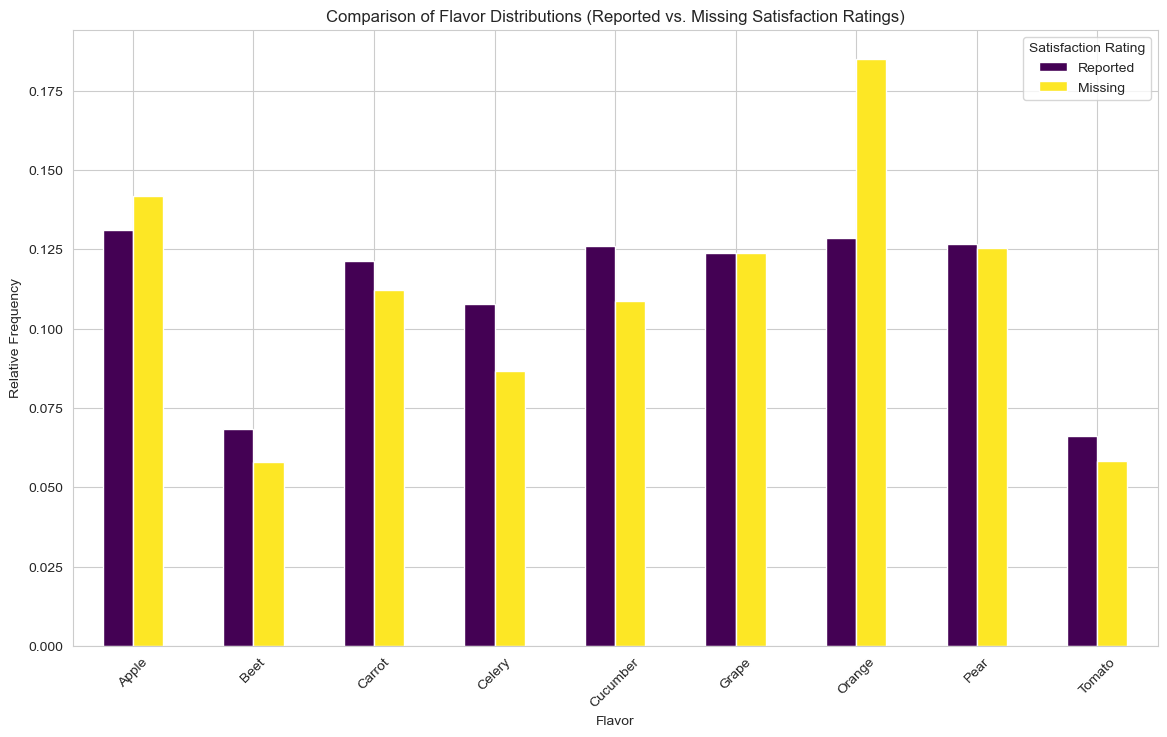

In [88]:
# Analysis of Missing Data in Product Satisfaction Rating

# Construct the relative frequency distribution of records over the values of the Product Satisfaction Rating variable
product_satisfaction_freq = ejb_df['Product Satisfaction Rating'].value_counts(normalize=True, dropna=False)

# Display the relative frequency distribution
print("Relative Frequency Distribution of Product Satisfaction Rating:")
print(product_satisfaction_freq)

# Plot the relative frequency distribution
plt.figure(figsize=(10, 6))
sns.barplot(x=product_satisfaction_freq.index, y=product_satisfaction_freq.values, palette='viridis')
plt.title('Relative Frequency Distribution of Product Satisfaction Rating')
plt.xlabel('Product Satisfaction Rating')
plt.ylabel('Relative Frequency')
plt.xticks(rotation=45)
plt.show()

# Calculate the percentage of records missing a value for Product Satisfaction Rating
missing_percentage = product_satisfaction_freq.loc[np.nan] * 100
print(f"Percentage of records missing Product Satisfaction Rating: {missing_percentage:.2f}%")

# Considering only records that report values of Product Satisfaction Rating
reported_satisfaction_df = ejb_df.dropna(subset=['Product Satisfaction Rating'])

# Construct the relative frequency distribution of records over the different flavors
flavor_freq_reported = reported_satisfaction_df['Flavor'].value_counts(normalize=True)

# Display the relative frequency distribution for reported satisfaction ratings
print("Relative Frequency Distribution of Flavors (Reported Satisfaction Ratings):")
print(flavor_freq_reported)

# Plot the relative frequency distribution for reported satisfaction ratings
plt.figure(figsize=(10, 6))
sns.barplot(x=flavor_freq_reported.index, y=flavor_freq_reported.values, palette='viridis')
plt.title('Relative Frequency Distribution of Flavors (Reported Satisfaction Ratings)')
plt.xlabel('Flavor')
plt.ylabel('Relative Frequency')
plt.xticks(rotation=45)
plt.show()

# Considering records that are missing values of Product Satisfaction Rating
missing_satisfaction_df = ejb_df[ejb_df['Product Satisfaction Rating'].isna()]

# Construct the relative frequency distribution of records over the different flavors
flavor_freq_missing = missing_satisfaction_df['Flavor'].value_counts(normalize=True)

# Display the relative frequency distribution for missing satisfaction ratings
print("Relative Frequency Distribution of Flavors (Missing Satisfaction Ratings):")
print(flavor_freq_missing)

# Plot the relative frequency distribution for missing satisfaction ratings
plt.figure(figsize=(10, 6))
sns.barplot(x=flavor_freq_missing.index, y=flavor_freq_missing.values, palette='viridis')
plt.title('Relative Frequency Distribution of Flavors (Missing Satisfaction Ratings)')
plt.xlabel('Flavor')
plt.ylabel('Relative Frequency')
plt.xticks(rotation=45)
plt.show()

# Compare the distributions in part (b) and part (c)
comparison_df = pd.DataFrame({
    'Reported': flavor_freq_reported,
    'Missing': flavor_freq_missing
}).fillna(0)

# Plot the comparison of distributions
comparison_df.plot(kind='bar', figsize=(14, 8), colormap='viridis')
plt.title('Comparison of Flavor Distributions (Reported vs. Missing Satisfaction Ratings)')
plt.xlabel('Flavor')
plt.ylabel('Relative Frequency')
plt.xticks(rotation=45)
plt.legend(title='Satisfaction Rating')
plt.show()

# Data Cleaning
Validate that the Employee-Attritionv1.csv data is clean and include the code for validation.

In [78]:
# Data Cleaning

# Display basic information about the dataset
print("Basic Information about Employee-Attrition Dataset:")
print(employee_attrition_df.info(), "\n")

# Check for missing values in the dataset
missing_values = employee_attrition_df.isnull().sum()
print("Missing Values in Employee-Attrition Dataset:")
print(missing_values[missing_values > 0], "\n")

# Check for duplicate rows in the dataset
duplicate_rows = employee_attrition_df.duplicated().sum()
print(f"Number of Duplicate Rows in Employee-Attrition Dataset: {duplicate_rows}\n")

# Display summary statistics for numerical columns
print("Summary Statistics for Numerical Columns:")
print(employee_attrition_df.describe(), "\n")

# Display summary statistics for categorical columns
print("Summary Statistics for Categorical Columns:")
print(employee_attrition_df.describe(include=['object']), "\n")

# Check for unique values in each categorical column
print("Unique Values in Categorical Columns:")
for col in employee_attrition_df.select_dtypes(include=['object']).columns:
    print(f"{col}: {employee_attrition_df[col].nunique()} unique values")

# Validate that the data is clean
# If there are no missing values, no duplicate rows, and the summary statistics look reasonable, the data is considered clean.

Basic Information about Employee-Attrition Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1470 non-null   float64
 1   Attrition                 1470 non-null   object 
 2   BusinessTravel            1470 non-null   object 
 3   DailyRate                 1470 non-null   float64
 4   Department                1470 non-null   object 
 5   DistanceFromHome          1470 non-null   float64
 6   Education                 1470 non-null   float64
 7   EducationField            1470 non-null   object 
 8   EmployeeCount             1470 non-null   float64
 9   EmployeeNumber            1470 non-null   float64
 10  EnvironmentSatisfaction   1470 non-null   float64
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   float64
 13  JobInvolvem

# Exploratory Data Analysis (EDA)
Explore the Employee-Attritionv1.csv data for further analysis and include code for EDA.

In [79]:
# Exploratory Data Analysis (EDA)

# Display the first few rows of the Employee-Attrition dataset
print("First few rows of Employee-Attrition Dataset:")
print(employee_attrition_df.head(), "\n")

# Display the basic information about the dataset
print("Basic Information about Employee-Attrition Dataset:")
print(employee_attrition_df.info(), "\n")

# Check for missing values in the dataset
missing_values = employee_attrition_df.isnull().sum()
print("Missing Values in Employee-Attrition Dataset:")
print(missing_values[missing_values > 0], "\n")

# Check for duplicate rows in the dataset
duplicate_rows = employee_attrition_df.duplicated().sum()
print(f"Number of Duplicate Rows in Employee-Attrition Dataset: {duplicate_rows}\n")

# Display summary statistics for numerical columns
print("Summary Statistics for Numerical Columns:")
print(employee_attrition_df.describe(), "\n")

# Display summary statistics for categorical columns
print("Summary Statistics for Categorical Columns:")
print(employee_attrition_df.describe(include=['object']), "\n")

# Check for unique values in each categorical column
print("Unique Values in Categorical Columns:")
for col in employee_attrition_df.select_dtypes(include=['object']).columns:
    print(f"{col}: {employee_attrition_df[col].nunique()} unique values")

# Plot the distribution of numerical features
numerical_cols = employee_attrition_df.select_dtypes(include=['int64', 'float64']).columns
employee_attrition_df[numerical_cols].hist(bins=15, figsize=(15, 10), layout=(5, 4))
plt.suptitle('Distribution of Numerical Features')
plt.show()

# Plot the distribution of categorical features
categorical_cols = employee_attrition_df.select_dtypes(include=['object']).columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(3, 3, i)
    sns.countplot(y=col, data=employee_attrition_df, palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.tight_layout()

plt.show()

# Plot the correlation matrix
plt.figure(figsize=(15, 10))
correlation_matrix = employee_attrition_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# Pairplot of numerical features
sns.pairplot(employee_attrition_df[numerical_cols])
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

# Boxplot of numerical features grouped by Attrition
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(5, 4, i)
    sns.boxplot(x='Attrition', y=col, data=employee_attrition_df, palette='viridis')
    plt.title(f'{col} by Attrition')
    plt.tight_layout()

plt.show()

First few rows of Employee-Attrition Dataset:
    Age Attrition     BusinessTravel  DailyRate              Department  \
0  41.0       Yes      Travel_Rarely     1102.0                   Sales   
1  49.0        No  Travel_Frequently      279.0  Research & Development   
2  37.0       Yes      Travel_Rarely     1373.0  Research & Development   
3  33.0        No  Travel_Frequently     1392.0  Research & Development   
4  27.0        No      Travel_Rarely      591.0  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0               1.0        2.0  Life Sciences            1.0             1.0   
1               8.0        1.0  Life Sciences            1.0             2.0   
2               2.0        2.0          Other            1.0             4.0   
3               3.0        4.0  Life Sciences            1.0             5.0   
4               2.0        1.0        Medical            1.0             7.0   

   ...  RelationshipSa

ValueError: Layout of 5x4 must be larger than required size 26

# Useful Visualizations
Identify and create the most useful visualizations for the Employee-Attritionv1.csv dataset.

In [ ]:
# Useful Visualizations

# Plot the distribution of numerical features
numerical_cols = employee_attrition_df.select_dtypes(include=['int64', 'float64']).columns
employee_attrition_df[numerical_cols].hist(bins=15, figsize=(15, 10), layout=(5, 4))
plt.suptitle('Distribution of Numerical Features')
plt.show()

# Plot the distribution of categorical features
categorical_cols = employee_attrition_df.select_dtypes(include=['object']).columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(3, 3, i)
    sns.countplot(y=col, data=employee_attrition_df, palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.tight_layout()

plt.show()

# Plot the correlation matrix
plt.figure(figsize=(15, 10))
correlation_matrix = employee_attrition_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# Pairplot of numerical features
sns.pairplot(employee_attrition_df[numerical_cols])
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

# Boxplot of numerical features grouped by Attrition
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(5, 4, i)
    sns.boxplot(x='Attrition', y=col, data=employee_attrition_df, palette='viridis')
    plt.title(f'{col} by Attrition')
    plt.tight_layout()

plt.show()

# Machine Learning Applications
Discuss how machine learning could be useful in exploring the Employee-Attritionv1.csv dataset.

In [ ]:
# Machine Learning Applications

# Import necessary libraries for machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Prepare the data for machine learning
# Drop columns that are not useful for prediction
employee_attrition_ml_df = employee_attrition_df.drop(columns=['EmployeeNumber', 'EmployeeCount', 'Over18', 'StandardHours'])

# Convert categorical variables to dummy variables
employee_attrition_ml_df = pd.get_dummies(employee_attrition_ml_df, drop_first=True)

# Define the feature matrix (X) and the target vector (y)
X = employee_attrition_ml_df.drop(columns=['Attrition_Yes'])
y = employee_attrition_ml_df['Attrition_Yes']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardize the feature matrix
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train a Random Forest classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_classifier.predict(X_test)

# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature importance
feature_importances = pd.Series(rf_classifier.feature_importances_, index=X.columns)
feature_importances.nlargest(10).plot(kind='barh', figsize=(10, 6), colormap='viridis')
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

# Data Fluency Discussion
Discuss the value of data fluency as a new manager of a Data Science function in a Financial Services company.

In [ ]:
# Data Fluency Discussion

# Data fluency is the ability to understand, analyze, and communicate data effectively. As a new manager of a Data Science function in a Financial Services company, data fluency is crucial for several reasons:

# 1. **Informed Decision Making**: Data fluency enables you to make data-driven decisions, which are more likely to be accurate and effective. By understanding the data, you can identify trends, patterns, and insights that can inform strategic decisions.

# 2. **Effective Communication**: Being data fluent allows you to communicate complex data insights to non-technical stakeholders in a clear and concise manner. This is essential for gaining buy-in and support for data-driven initiatives.

# 3. **Identifying Opportunities**: Data fluency helps you identify new opportunities for growth and improvement. By analyzing data, you can uncover areas where the company can optimize processes, reduce costs, and increase revenue.

# 4. **Risk Management**: In the Financial Services industry, managing risk is critical. Data fluency allows you to analyze risk factors and develop strategies to mitigate them. This can help protect the company from potential financial losses.

# 5. **Enhancing Customer Experience**: Understanding customer data can help you tailor products and services to meet their needs better. Data fluency enables you to analyze customer behavior and preferences, leading to improved customer satisfaction and loyalty.

# 6. **Staying Competitive**: In today's data-driven world, companies that leverage data effectively have a competitive advantage. Data fluency ensures that you can keep up with industry trends and stay ahead of competitors.

# 7. **Building a Data-Driven Culture**: As a manager, you play a key role in fostering a data-driven culture within your team. By being data fluent, you can lead by example and encourage your team to use data in their daily work.

# In summary, data fluency is a valuable skill for a manager in a Data Science function. It empowers you to make informed decisions, communicate effectively, identify opportunities, manage risks, enhance customer experience, stay competitive, and build a data-driven culture.